<p align="center"><font size="6"><b>Notebook de Charles-Henri SAINT-MARS</b></font></p>

# **NumPy**

Numpy est une bibliothèque Python qui fournit des structures de données pour travailler avec des tableaux multidimensionnels. Elle est utilisée pour effectuer des calculs mathématiques et logiques sur ces tableaux. Elle est très utile pour effectuer des opérations sur des tableaux et des matrices. Elle est également utilisée pour effectuer des opérations de calcul sur des tableaux multidimensionnels. <br>
Numpy est une bibliothèque open source et gratuite. Elle est très populaire parmi les développeurs de logiciels et les chercheurs en informatique. Elle est également utilisée dans de nombreux domaines tels que la science des données, l'apprentissage automatique, l'intelligence artificielle, etc. <br>
Numpy a été développé par Travis Oliphant en 2005. Il est écrit en langage de programmation Python et C. Il est disponible sous licence BSD. Il est également disponible sous forme de bibliothèque Python standard.

## N-dimensional array (ndarray)

Un `ndarray` (abréviation de N-dimensional array) est la structure de données principale dans la bibliothèque NumPy. C'est un tableau multidimensionnel d'éléments de même type, permettant des opérations rapides et efficaces sur des ensembles de données numériques.

Voici quelques points clés à propos des `ndarray` :

Caractéristiques d'un `ndarray` :
Dimensionnalité : Comme son nom l'indique, un `ndarray` peut avoir un nombre arbitraire de dimensions. Un tableau à 1 dimension est équivalent à une liste Python, un tableau à 2 dimensions peut être vu comme une matrice, et un tableau à N dimensions est plus général.

Homogénéité des données : Tous les éléments d'un `ndarray` sont du même type de données (par exemple, tous des entiers, des flottants, etc.). Cela permet d'optimiser les opérations et l'utilisation de la mémoire.

Attributs importants :

`ndarray.shape` : Renvoie une tuple décrivant les dimensions du tableau (nombre de lignes, colonnes, etc.). <br>
`ndarray.ndim` : Renvoie le nombre de dimensions du tableau. <br>
`ndarray.size` : Renvoie le nombre total d'éléments dans le tableau. <br>
`ndarray.dtype` : Indique le type des éléments du tableau (ex. int32, float64, etc.).

**Différence avec les listes Python :** <br>
Contrairement aux listes Python, un `ndarray` est plus performant pour des calculs mathématiques et des opérations sur de grandes quantités de données grâce à l'utilisation de types homogènes et de structures mémoire contiguës.

En résumé, un `ndarray` est une structure optimisée pour les opérations scientifiques et numériques dans Python, idéale pour manipuler des tableaux de données multidimensionnels.

In [1]:
# Importation des modules
import numpy as np
from time import time # Pour mesurer le temps d'exécution
from sklearn.datasets import load_digits # Pour charger la base de données digits
import matplotlib.pyplot as plt # Pour l'affichage d'images

In [2]:
np.ones(shape=(4, 3)) # Création d'un tableau de 4 lignes et 3 colonnes rempli de 1

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [3]:
np.zeros(shape=(3, 4)) # Création d'un tableau de 3 lignes et 4 colonnes rempli de 0

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [4]:
mA = np.random.randint(0, 10, size=(4, 3)) # Création d'un tableau de 4 lignes et 3 colonnes rempli de nombres aléatoires entre 0 et 10 (10 est non inclus)
mA

array([[2, 0, 3],
       [2, 9, 0],
       [2, 8, 4],
       [4, 7, 1]], dtype=int32)

In [5]:
type(mA) # Affiche le type de la variable mA

numpy.ndarray

In [6]:
liste = [[5, 5, 6],
        [8, 5, 8],
        [8, 8, 7],
        [0, 0, 2]]
liste

[[5, 5, 6], [8, 5, 8], [8, 8, 7], [0, 0, 2]]

In [7]:
mB = np.array(liste) # Création d'un tableau à partir d'une liste
mB

array([[5, 5, 6],
       [8, 5, 8],
       [8, 8, 7],
       [0, 0, 2]])

In [8]:
mB.ndim # Affiche le nombre de dimensions du tableau

2

In [9]:
mB.shape # Affiche le nombre de lignes et de colonnes du tableau

(4, 3)

In [10]:
mB.T # Transposée du tableau

array([[5, 8, 8, 0],
       [5, 5, 8, 0],
       [6, 8, 7, 2]])

In [11]:
mC = np.random.randint(0, 10, size=(4, 3))
mD = np.random.randint(0, 10, size=(3, 4))

In [12]:
mC.shape, mD.shape
# Le nombre de colonnes de mC est égal au nombre de lignes de mD

((4, 3), (3, 4))

In [13]:
# Multiplication de mC par mD
mE = np.dot(mC, mD)
mE

array([[124, 101, 129, 125],
       [ 52,  46,  62,  46],
       [ 89,  30,  79,  37],
       [ 85,  36,  75,  49]], dtype=int32)

In [14]:
# Fonction de multiplication matrcielle
def produit_matriciel(matrice1, matrice2) -> list:
  shape_matrix1 = shape(matrice1)
  shape_matrix2 = shape(matrice2)
  # print(f"shape de {matrice1} est {shape_matrix1}, shape de {matrice2} est {shape_matrix2}") # Afficher les dimensions des matrices
  assert shape_matrix1[1] == shape_matrix2[0], "Le nombre de colonnes de la première matrice doit être égal au nombre de lignes de la deuxième matrice"
  return [[sum([a * b for a, b in zip(ligne1, colonne2)]) for colonne2 in zip(*matrice2)] for ligne1 in matrice1]


# Fonction shape pour retourner le nombre de lignes et de colonnes d'une matrice
def shape(matrice):
  return len(matrice), len(matrice[0])

In [15]:
# Mesure du temps d'exécution de la fonction produit_matriciel
start = time()
n_loops = 1000
for _ in range(n_loops):
  produit_matriciel(mC, mD)
end = time()
t_python = (end - start)/n_loops
print("Temps d'exécution moyen : ", t_python, " secondes")

Temps d'exécution moyen :  6.799745559692383e-05  secondes


In [16]:
# Mesure du temps d'exécution de la fonction np.dot
start = time()
n_loops = 1000
for _ in range(n_loops):
  np.dot(mC, mD)
end = time()
t_numpy = (end - start)/n_loops
print("Temps d'exécution moyen : ", t_numpy, " secondes")

Temps d'exécution moyen :  4.001140594482422e-06  secondes


In [17]:
print("La fonction np.dot de numpy est %.2f fois plus rapide que la fonction produit matriciel en python pur" % (t_python/t_numpy))

La fonction np.dot de numpy est 16.99 fois plus rapide que la fonction produit matriciel en python pur


### Numpy Reschape

In [18]:
mG = np.ones(shape=(3, 4, 5)) # Création d'un tableau de 3 matrices de 4 lignes et 5 colonnes rempli de 1
mG
# Nous avons un tableau de 3 x 4 x 5 soient 60 éléments

array([[[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]],

       [[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]])

In [19]:
mG.shape # Affiche le nombre de matrices, de lignes et de colonnes du tableau

(3, 4, 5)

In [20]:
mG.size # Affiche le nombre total d'éléments du tableau

60

In [21]:
mG.reshape(60) # Transformation du tableau en un tableau à une seule dimension

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [22]:
mG.reshape(3, 20) # Transformation du tableau en un tableau de 3 lignes et 20 colonnes

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.]])

In [23]:
mG.reshape(3, 5, 4) # Transformation du tableau en un tableau de 3 matrices de 5 lignes et 4 colonnes

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]])

In [24]:
mH = np.arange(60) # Création d'un tableau de 60 éléments allant de 0 à 59
mH

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59])

In [25]:
mH.reshape(3, 4, 5) # Transformation du tableau en un tableau de 3 matrices de 4 lignes et 5 colonnes

array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]],

       [[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39]],

       [[40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54],
        [55, 56, 57, 58, 59]]])

In [26]:
mH.shape

(60,)

In [27]:
mH.size # Affiche le nombre total d'éléments du tableau

60

La méthode reshape() conserve l'ordre des éléments ainsi que le nombre d'éléments

In [28]:
# Utilisation du joker -1 pour laisser numpy déterminer la dimension manquante
mH.reshape(3, -1, 5) # Transformation du tableau en un tableau de 3 matrices de 4 lignes et 5 colonnes

array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]],

       [[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39]],

       [[40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54],
        [55, 56, 57, 58, 59]]])

In [29]:
mH.reshape(3, 4, -1) # Transformation du tableau en un tableau de 3 matrices de 4 lignes et 5 colonnes

array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]],

       [[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39]],

       [[40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54],
        [55, 56, 57, 58, 59]]])

In [30]:
mH.reshape(3, 5, -1).shape # Transformation du tableau en un tableau de 3 matrices de 5 lignes et 4 colonnes

(3, 5, 4)

### Utilisation de sklearn.datasets et de matplotlib.pyplot

In [31]:
digits = load_digits()['images']

In [32]:
type(digits)

numpy.ndarray

In [33]:
digits

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [34]:
digits.shape

(1797, 8, 8)

In [35]:
digits.size

115008

In [36]:
digits[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

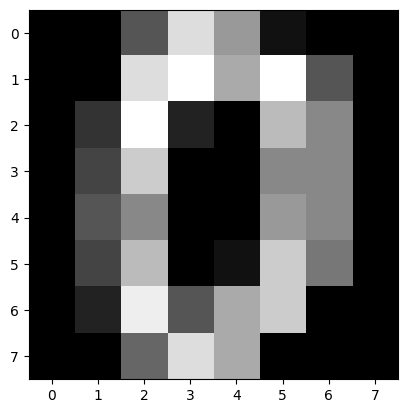

In [37]:
plt.imshow(digits[0], cmap='gray')
plt.draw()

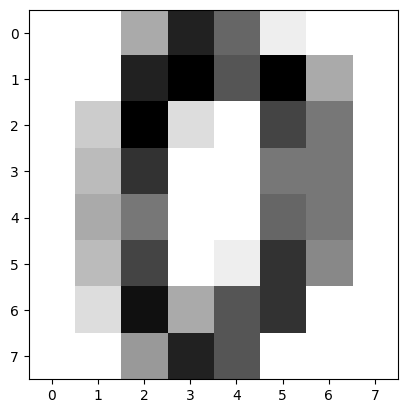

In [38]:
plt.imshow(digits[0], cmap='binary')
plt.draw()

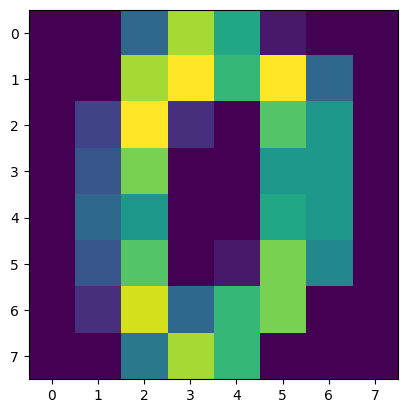

In [39]:
plt.imshow(digits[0])
plt.draw()

In [40]:
mJ = np.arange(60)
mJ

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59])

In [41]:
mJ = mJ.reshape(6, 10)
mJ

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54, 55, 56, 57, 58, 59]])

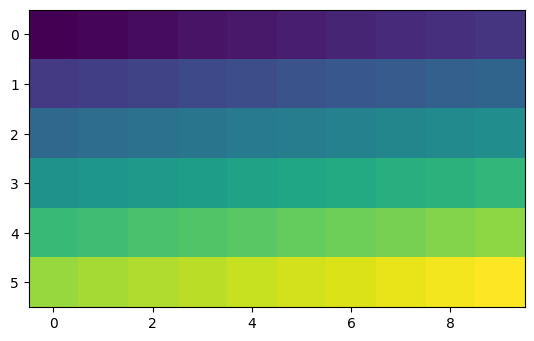

In [42]:
plt.imshow(mJ)
plt.draw()

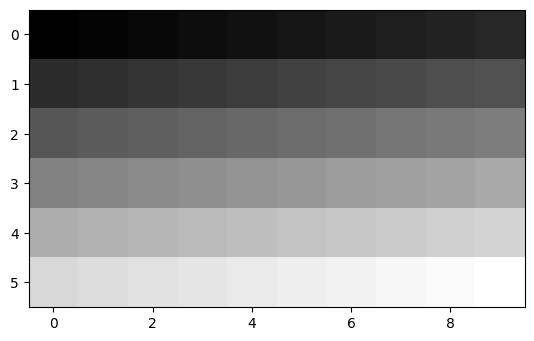

In [43]:
plt.imshow(mJ, cmap='gray')
plt.draw()

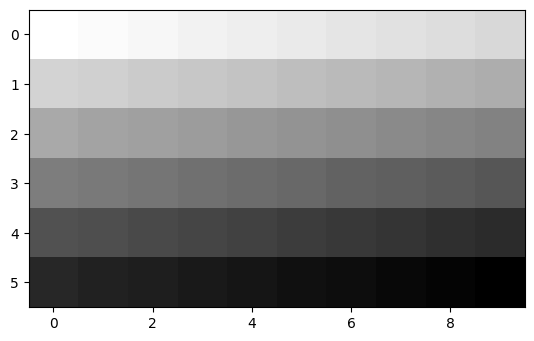

In [44]:
plt.imshow(mJ, cmap='binary')
plt.draw()

### Les opérations element-wise

Les opérations element-wise sont des opérations qui sont effectuées élément par élément sur les tableaux numpy. Ces opérations sont effectuées sur des tableaux de même forme. Les opérations element-wise sont effectuées en utilisant des opérateurs arithmétiques tels que +, -, *, /, %, etc.

In [45]:
# Element-wise operations
print("Element-wise operations :")
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

# Addition element-wise
print("Addition :")
print(a + b)  # [11 22 33 44]

# Multiplication element-wise
print("Multiplication :")
print(a * b)  # [10 40 90 160]

Element-wise operations :
Addition :
[11 22 33 44]
Multiplication :
[ 10  40  90 160]


### Le broadcasting

Le broadcasting est un mécanisme puissant qui permet à numpy d'effectuer des opérations sur des tableaux de formes différentes. Il étend automatiquement les tableaux pour qu'ils aient la même forme. Cela signifie que vous pouvez effectuer des opérations sur des tableaux de formes différentes sans avoir à les convertir en la même forme.

In [46]:
# Broadcasting
print("\nBroadcasting :")
x = np.array([1, 2, 3, 4])
y = np.array([10])

# Addition avec broadcasting
print("Addition avec broadcasting :")
print(x + y)  # [11 12 13 14]

# Multiplication avec broadcasting
print("Multiplication avec broadcasting :")
print(x * y)  # [10 20 30 40]


Broadcasting :
Addition avec broadcasting :
[11 12 13 14]
Multiplication avec broadcasting :
[10 20 30 40]


In [47]:
# Broadcasting et addition entre un vecteur et un scalaire
x = np.array([1, 2, 3, 4])
y = 10
print("Broadcasting et addition entre un vecteur et un scalaire :")
print(x + y)  # [11 12 13 14]

Broadcasting et addition entre un vecteur et un scalaire :
[11 12 13 14]


In [48]:
# Broadcasting et soustraction entre un vecteur et un scalaire
x = np.array([1, 2, 3, 4])
y = 10
print("Broadcasting et soustraction entre un vecteur et un scalaire :")
print(y - x)  # [9 8 7 6]

Broadcasting et soustraction entre un vecteur et un scalaire :
[9 8 7 6]


In [49]:
# Exemple plus complexe de broadcasting
print("\nExemple plus complexe de broadcasting :")
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
b = np.array([10, 20, 30]) # b est étendu à [[10, 20, 30], [10, 20, 30], [10, 20, 30]]

print("Forme de a :", a.shape)  # (3, 3)
print("Forme de b :", b.shape)  # (3,)

# NumPy étend b pour correspondre à la forme de a
result = a + b
print("Résultat :")
print(result)


Exemple plus complexe de broadcasting :
Forme de a : (3, 3)
Forme de b : (3,)
Résultat :
[[11 22 33]
 [14 25 36]
 [17 28 39]]


### Le masking

Le masking est un mécanisme qui permet de sélectionner des éléments d'un tableau numpy en fonction d'une condition. Il est utilisé pour filtrer les éléments d'un tableau numpy en fonction d'une condition. Le masking est effectué en utilisant des opérateurs de comparaison tels que ==, !=, <, >, etc. Le masque est un tableau de booléens qui indique quels éléments du tableau d'origine doivent être sélectionnés. Il sert à indexer les éléments du tableau d'origine.

In [50]:
mT = np.arange(12).reshape(3, 4)
mT

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [51]:
mask = [False, True, False]
mT[mask]

array([[4, 5, 6, 7]])

In [52]:
mask = mT % 2 == 0
mask

array([[ True, False,  True, False],
       [ True, False,  True, False],
       [ True, False,  True, False]])

In [53]:
mT[mask]

array([ 0,  2,  4,  6,  8, 10])

In [54]:
mask = mT > 5
mask

array([[False, False, False, False],
       [False, False,  True,  True],
       [ True,  True,  True,  True]])

In [55]:
mT[mask]

array([ 6,  7,  8,  9, 10, 11])

In [56]:
# Compter le nombre d'élément supérieur à 5
np.sum(mask)

np.int64(6)

In [57]:
# Calculer la proportion des élément supérieur à 5
mask.sum()/mask.size

np.float64(0.5)

### La méthode sum() d'un tableau numpy (dit ndarray)

La méthode sum() est utilisée pour calculer la somme des éléments d'un tableau numpy. Elle prend en paramètre l'axe sur lequel la somme doit être calculée. Par défaut, l'axe est None, ce qui signifie que la somme est calculée sur tous les éléments du tableau. Si l'axe est spécifié, la somme est calculée sur les éléments de cet axe.

In [58]:
mT

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [59]:
mT.sum() # Somme de tous les éléments

np.int64(66)

In [60]:
# Les axes dans numpy
# axis = 0 # axe des index des lignes (dit aussi vertical car les index des lignes sont sur l'axe vertical)
# axis = 1 # axe des index des colonnes (dit aussi horizontal car les index des colonnes sont sur l'axe horizontal)

In [61]:
mT.sum(axis=0) # Somme des éléments de chaque colonne (les colonnes sont orientées sur l'axe des index des lignes)

array([12, 15, 18, 21])

In [62]:
mT.sum(axis=1) # Somme des éléments de chaque ligne (les lignes sont orientées sur l'axe des index des colonnes)

array([ 6, 22, 38])

In [63]:
mT.sum(axis=1, keepdims=True) # Somme des éléments de chaque ligne avec le même nombre de dimensions que mT

array([[ 6],
       [22],
       [38]])

### Le numpy slicing

In [64]:
mU = np.arange(10, 60) # Création d'un tableau d'éléments allant de 10 à 59 soient 50 éléments
mU

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59])

In [65]:
mU =mU.reshape(10, -1) # Transformation du tableau en un tableau de 10 lignes et 5 colonnes
mU

array([[10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54],
       [55, 56, 57, 58, 59]])

In [66]:
mU[0] # Affiche la première ligne

array([10, 11, 12, 13, 14])

In [67]:
mU[0:2] # Affiche les deux premières lignes

array([[10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [68]:
mU[1][2] # Affiche l'élément à la deuxième ligne et à la troisième colonne

np.int64(17)

In [69]:
mU[1, 2] # Affiche l'élément à la deuxième ligne et à la troisième colonne. On préférera cette notation.

np.int64(17)

In [70]:
mU[0, 2:4] # Affiche les éléments de la première ligne et des colonnes 3 et 4. On préférera utiliser mU[0, 2:4] à mU[0][2:4].

array([12, 13])

In [71]:
mU[1:3, 2:4] # Affiche les éléments des lignes 2 et 3 et des colonnes 3 et 4

array([[17, 18],
       [22, 23]])

In [72]:
mU[:, 2] # Toutes les lignes de la 3ème colonne

array([12, 17, 22, 27, 32, 37, 42, 47, 52, 57])

In [73]:
mV = np.arange(2*3*4).reshape(2, 3, -1) # Création d'un tableau de 2 matrices de 3 lignes et 4 colonnes (tenseur de rang 3)
mV

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [74]:
mV[:,:,:]

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [75]:
mV[:,:,0] # Toutes les matrices, toutes les lignes et la première colonne

array([[ 0,  4,  8],
       [12, 16, 20]])

In [76]:
mV[0,:,0] # La première matrice, toutes les lignes et la première colonne

array([0, 4, 8])